# Product & Category Trends

Notebook นี้โฟกัสที่ **behavioral product dynamics** ของลูกค้า Instacart โดยตอบ 5 คำถามหลัก:

1. **Market Share & Category Dominance** — แต่ละ segment ใช้สัดส่วนกับหมวดไหนมากที่สุด
2. **Weekly Rhythm: DOW x Category Boom** — แต่ละวันของสัปดาห์มี category signature อย่างไร
3. **Order Sequence Evolution** — สินค้าไหนเป็น `Gateway` และสินค้าไหนกลายเป็น `Habit`
4. **Product Velocity & Decay** — สินค้าไหนมีรอบซื้อซ้ำเร็วและผูกกับ threshold `15 วัน`
5. **Basket Intensity & Cross-Selling** — ตะกร้าแน่นและหลากหลายที่สุดเมื่อไร

> หมายเหตุ: dataset นี้ไม่มีราคา/ยอดเงินต่อ SKU โดยตรง ดังนั้น notebook จะใช้ **order lines เป็น spend proxy** เวลาพูดถึง `share of wallet`

In [1]:
import sys
import warnings
import datetime as dt
from pathlib import Path

import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [2]:
DATA_PATH = '../../data/processed/quality'

orders               = pl.scan_csv(Path(DATA_PATH) / 'orders_clean.csv').collect()
order_products_prior = pl.scan_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv').collect()
order_products_train = pl.scan_csv(Path(DATA_PATH) / 'order_products_train_clean.csv').collect()
products             = pl.scan_csv(Path(DATA_PATH) / 'products_clean.csv').collect()
aisles               = pl.scan_csv(Path(DATA_PATH) / 'aisles_clean.csv').collect()
department           = pl.scan_csv(Path(DATA_PATH) / 'departments_clean.csv').collect()

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': department,
}

df = (
    orders
    .join(order_products_prior, on='order_id')
    .join(products.select(['product_id', 'aisle_id', 'department_id']), on='product_id', how='left')
    .join(aisles.select(['aisle_id', 'aisle']), on='aisle_id', how='left')
    .join(department.select(['department_id', 'department']), on='department_id', how='left')
    .drop(['aisle_id', 'department_id'])
)

## Analysis roadmap

- **Section 1**: Market Share & Category Dominance  
- **Section 2**: Weekly Rhythm — `DOW x Category Boom`  
- **Section 3**: Order Sequence Evolution — `Gateway vs Habit`  
- **Section 4**: Product Velocity & Decay — linked to the `15-day threshold`  
- **Section 5**: Basket Intensity & Cross-Selling

## 1) Market Share & Category Dominance

เริ่มจากดูว่าแต่ละ segment ใช้ `share of wallet proxy` ไปกับหมวดสินค้าไหนมากที่สุด โดยใน notebook นี้ใช้ **สัดส่วน order lines** แทนยอดใช้จ่ายจริง เพราะไม่มีข้อมูลราคาใน dataset

/tmp/ipykernel_418386/866429761.py:38: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replacing values.
(Deprecated in version 1.0.0)
  pl.col("order_dow").cast(pl.String).replace(


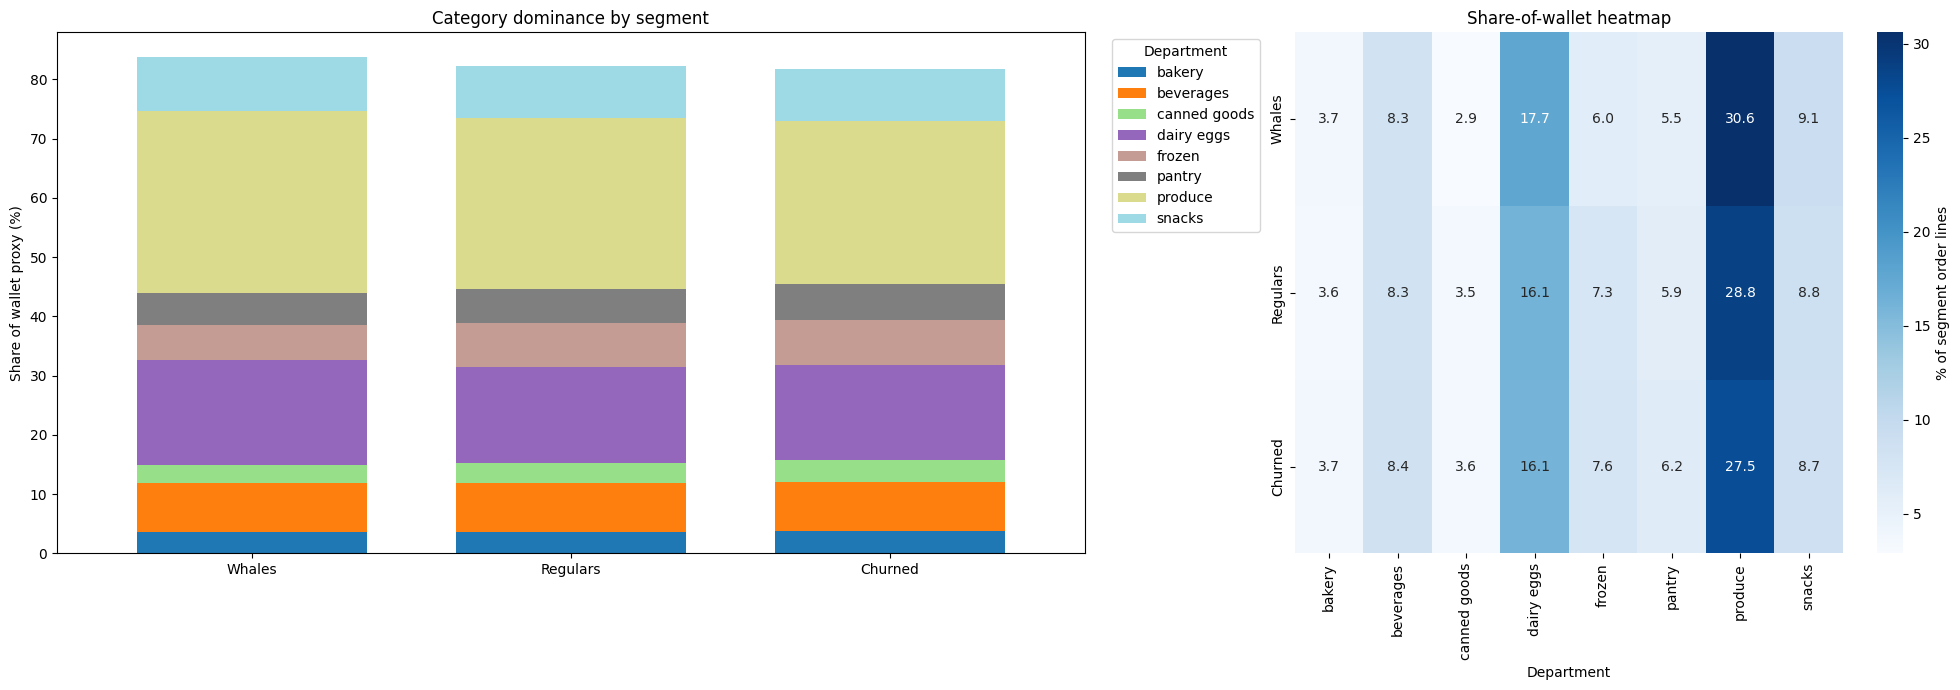

segment,department,share_of_wallet_proxy
str,str,f64
"""Churned""","""produce""",27.474347
"""Churned""","""dairy eggs""",16.060565
"""Churned""","""snacks""",8.721658
"""Churned""","""beverages""",8.372502
"""Churned""","""frozen""",7.562103
…,…,…
"""Whales""","""produce""",30.602679
"""Whales""","""dairy eggs""",17.745185
"""Whales""","""snacks""",9.135736


- Churned: dominant category = produce (27.5% share-of-wallet proxy)
- Regulars: dominant category = produce (28.8% share-of-wallet proxy)
- Whales: dominant category = produce (30.6% share-of-wallet proxy)


In [3]:
segment_order = ["Whales", "Regulars", "Churned"]
DOW_ORDER = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
TOP_N = 10

txn = df  # Polars is immutable; no copy needed

# -- Add product_name if missing --
if "product_name" not in txn.columns:
    txn = txn.join(
        tables["products"].select(["product_id", "product_name"]).unique(subset=["product_id"]),
        on="product_id",
        how="left",
    )

# -- Add order_date if missing --
if "order_date" not in txn.columns:
    candidate_paths = [
        Path("../../data/processed/features/orders_with_dates.csv"),
        Path("../data/processed/features/orders_with_dates.csv"),
        Path("data/processed/features/orders_with_dates.csv"),
    ]
    order_dates_path = next((p for p in candidate_paths if p.exists()), None)
    if order_dates_path is None:
        raise FileNotFoundError("orders_with_dates.csv not found in expected locations.")

    order_dates_df = pl.read_csv(str(order_dates_path)).with_columns(
        pl.col("order_date").str.to_date()
    )
    txn = txn.join(
        order_dates_df.select(["order_id", "order_date"]).unique(subset=["order_id"]),
        on="order_id",
        how="left",
    )

# -- Map day_name from integer order_dow --
dow_map = dict(enumerate(DOW_ORDER))
txn = txn.with_columns(
    pl.col("order_dow").cast(pl.String).replace(
        old=[str(k) for k in dow_map.keys()],
        new=list(dow_map.values()),
        return_dtype=pl.String,
    ).alias("day_name")
)

# -- Compute relative_day (cumulative days per customer) --
order_clock = (
    tables["orders"]
    .select(["order_id", "user_id", "order_number", "days_since_prior_order"])
    .sort(["user_id", "order_number"])
    .with_columns(pl.col("days_since_prior_order").fill_null(0))
    .with_columns(
        pl.col("days_since_prior_order").cum_sum().over("user_id").alias("relative_day")
    )
    .select(["order_id", "relative_day"])
)
txn = txn.join(order_clock, on="order_id", how="left")

# -- Customer segmentation --
customer_profile = (
    txn.group_by("user_id")
    .agg([
        pl.col("order_number").max().alias("total_orders"),
        pl.col("order_date").max().alias("last_order_date"),
    ])
)

_snapshot = txn["order_date"].cast(pl.Date).max() + dt.timedelta(days=1)
customer_profile = customer_profile.with_columns(
    (pl.lit(_snapshot) - pl.col("last_order_date").cast(pl.Date))
    .dt.total_days()
    .alias("days_since_last_order")
)

whale_threshold = customer_profile["total_orders"].quantile(0.90, interpolation="linear")
customer_profile = customer_profile.with_columns(
    pl.when(pl.col("days_since_last_order") > 30).then(pl.lit("Churned"))
    .when(pl.col("total_orders") >= whale_threshold).then(pl.lit("Whales"))
    .otherwise(pl.lit("Regulars"))
    .alias("segment")
)

txn = txn.join(customer_profile.select(["user_id", "segment"]), on="user_id", how="left")
df = txn

# -- Top departments & category share --
top_departments = (
    txn["department"].drop_nulls()
    .value_counts()
    .sort("count", descending=True)
    .head(8)["department"]
    .to_list()
)

category_share = (
    txn.group_by(["segment", "department"])
    .agg(pl.len().alias("order_lines"))
    .with_columns(
        pl.col("order_lines").sum().over("segment").alias("segment_total_lines")
    )
    .with_columns(
        (pl.col("order_lines") / pl.col("segment_total_lines") * 100)
        .alias("share_of_wallet_proxy")
    )
)

market_share_top = category_share.filter(pl.col("department").is_in(top_departments))

share_pivot = (
    market_share_top.to_pandas()
    .pivot(index="segment", columns="department", values="share_of_wallet_proxy")
    .reindex(segment_order)
    .fillna(0)
)

# -- Visualization --
fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1.5, 1]})
share_pivot.plot(kind="bar", stacked=True, ax=axes[0], width=0.72, colormap="tab20")
axes[0].set_title("Category dominance by segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share of wallet proxy (%)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Department", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

sns.heatmap(
    share_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=axes[1],
    cbar_kws={"label": "% of segment order lines"},
)
axes[1].set_title("Share-of-wallet heatmap")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

# Top-5 per segment
category_leaders = (
    market_share_top
    .select(["segment", "department", "share_of_wallet_proxy"])
    .with_columns(
        pl.col("share_of_wallet_proxy")
        .rank(method="ordinal", descending=True)
        .over("segment")
        .alias("_rank")
    )
    .filter(pl.col("_rank") <= 5)
    .drop("_rank")
    .sort(["segment", "share_of_wallet_proxy"], descending=[False, True])
)

display(category_leaders)

for row in (
    category_leaders
    .with_columns(
        pl.col("share_of_wallet_proxy")
        .rank(method="ordinal", descending=True)
        .over("segment")
        .alias("_rank")
    )
    .filter(pl.col("_rank") == 1)
    .drop("_rank")
    .iter_rows(named=True)
):
    print(f"- {row['segment']}: dominant category = {row['department']} ({row['share_of_wallet_proxy']:.1f}% share-of-wallet proxy)")

## 2) Weekly Rhythm: DOW x Category Boom

ส่วนนี้ใช้ `pd.crosstab(..., normalize='columns')` เพื่อดูว่าในแต่ละวันของสัปดาห์ หมวดไหนโดดเด่นกว่าปกติในแต่ละ segment

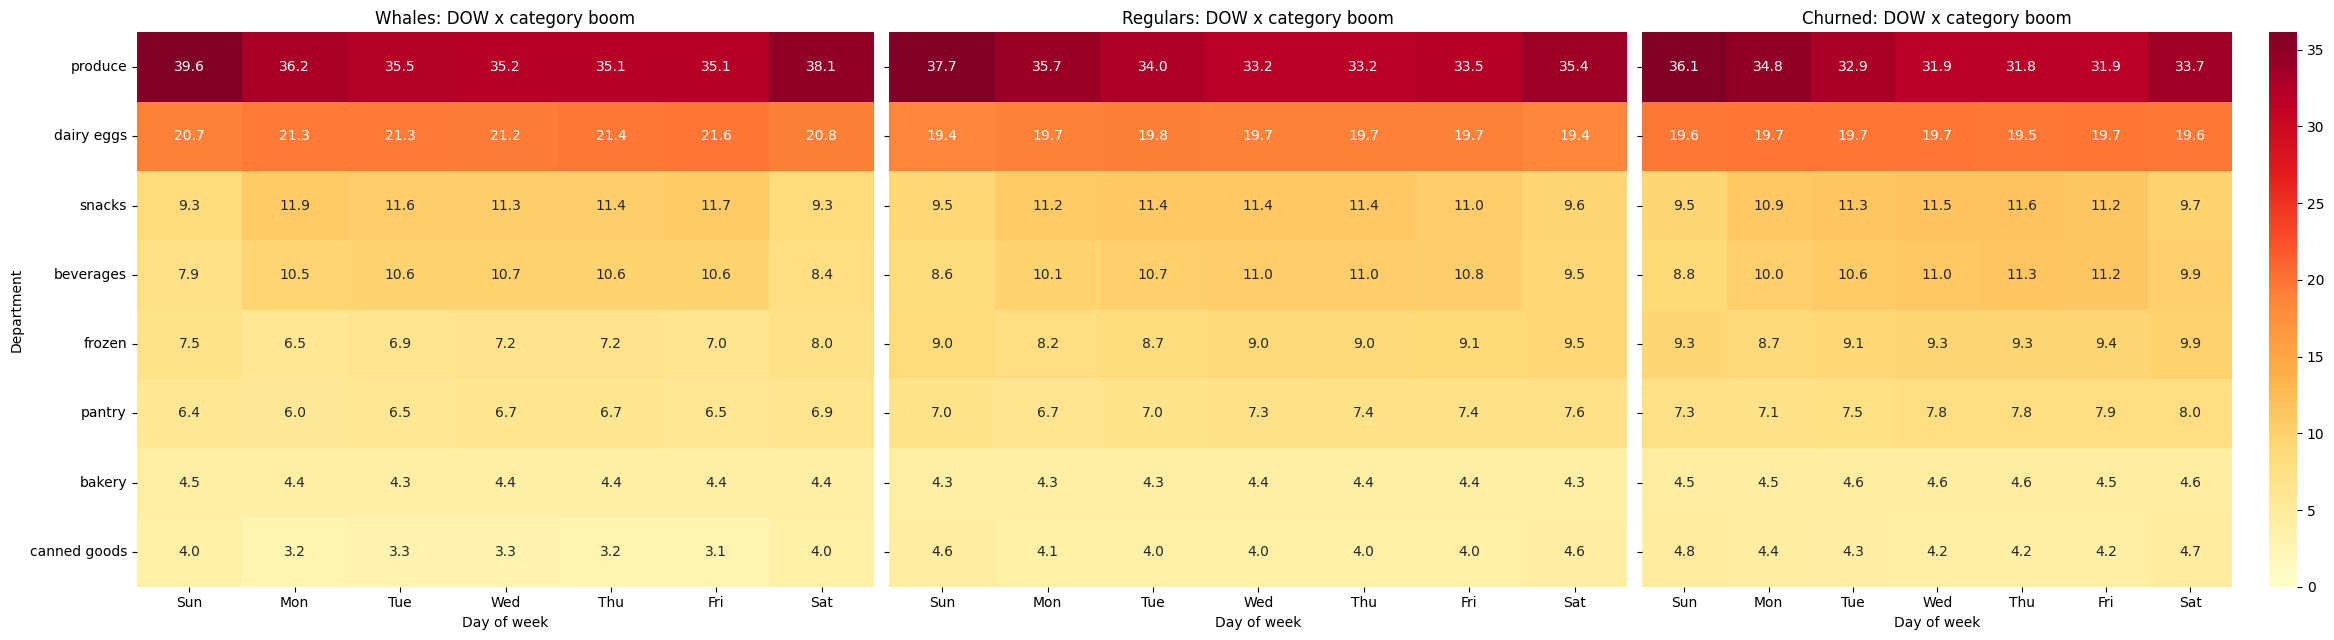

segment,department,day_name,share_pct
str,str,str,f64
"""Churned""","""bakery""","""Wed""",4.574471
"""Churned""","""beverages""","""Thu""",11.320779
"""Churned""","""canned goods""","""Sun""",4.794898
"""Churned""","""dairy eggs""","""Tue""",19.732024
"""Churned""","""frozen""","""Sat""",9.857266
…,…,…,…
"""Whales""","""dairy eggs""","""Fri""",21.589021
"""Whales""","""frozen""","""Sat""",8.013361
"""Whales""","""pantry""","""Sat""",6.919845


Example business use: deploy fresh/produce pushes on high-produce days and snack/beverage flash offers on their peak days.


In [4]:
weekly_focus = txn.filter(pl.col("department").is_in(top_departments))

fig, axes = plt.subplots(1, 3, figsize=(24, 6.5), sharey=True)
for ax, seg in zip(axes, segment_order):
    _seg_df = weekly_focus.filter(pl.col("segment") == seg)

    # Column-normalized crosstab: (dept × day) share per day
    heat = (
        _seg_df.group_by(["department", "day_name"])
        .agg(pl.len().alias("n"))
        .with_columns(
            (pl.col("n") / pl.col("n").sum().over("day_name") * 100).alias("pct")
        )
        .to_pandas()
        .pivot(index="department", columns="day_name", values="pct")
        .reindex(index=top_departments, columns=DOW_ORDER)
        .fillna(0)
    )

    sns.heatmap(
        heat,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        ax=ax,
        cbar=ax is axes[-1],
        vmin=0,
    )
    ax.set_title(f"{seg}: DOW x category boom")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Department" if ax is axes[0] else "")
plt.tight_layout()
plt.show()

# Peak day per (segment, department) — day with the highest share within that combo
peak_day_by_category = (
    weekly_focus
    .group_by(["segment", "department", "day_name"])
    .agg(pl.len().alias("order_lines"))
    .with_columns(
        pl.col("order_lines").sum().over(["segment", "day_name"]).alias("day_total")
    )
    .with_columns(
        (pl.col("order_lines") / pl.col("day_total") * 100).alias("share_pct")
    )
    .with_columns(
        pl.col("share_pct")
        .rank(method="ordinal", descending=True)
        .over(["segment", "department"])
        .alias("_rank")
    )
    .filter(pl.col("_rank") == 1)
    .drop("_rank")
    .select(["segment", "department", "day_name", "share_pct"])
    .sort(["segment", "department"])
)

display(peak_day_by_category)
print("Example business use: deploy fresh/produce pushes on high-produce days and snack/beverage flash offers on their peak days.")

## 3) Order Sequence Evolution: Gateway vs Habit Products

เราจะเปรียบเทียบสินค้าที่เด่นใน `order_number == 1` กับสินค้าที่ share โตขึ้นในช่วง `order_number > 5` เพื่อดูทั้ง **สินค้าดึงลูกค้าเข้าบ้าน** และ **สินค้าที่ก่อให้เกิดนิสัยซื้อซ้ำ**

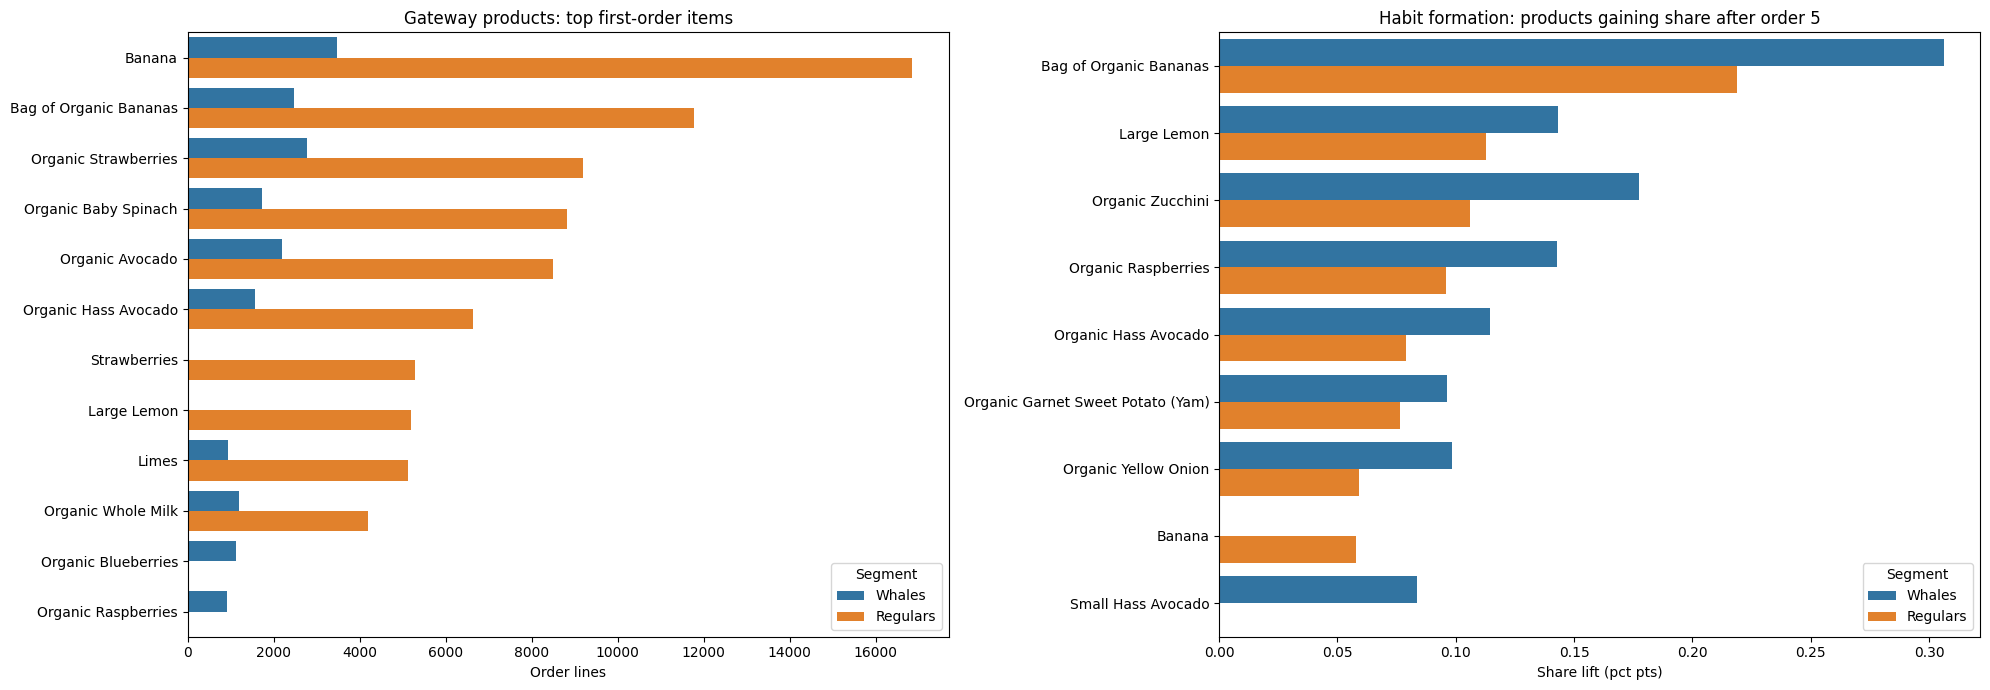

Gateway products by segment:


segment,product_name,order_lines
str,str,u32
"""Churned""","""Banana""",9222
"""Churned""","""Bag of Organic Bananas""",4903
"""Churned""","""Organic Strawberries""",4499
"""Churned""","""Organic Avocado""",4488
"""Churned""","""Organic Baby Spinach""",4385
…,…,…
"""Whales""","""Organic Hass Avocado""",1556
"""Whales""","""Organic Whole Milk""",1200
"""Whales""","""Organic Blueberries""",1131


Habit products gaining share:


segment,product_name,gateway_share,order_lines,habit_share,delta_habit_minus_gateway
str,str,f64,u32,f64,f64
"""Churned""","""Bag of Organic Bananas""",0.798257,4903,0.956169,0.157912
"""Churned""","""Organic Hass Avocado""",0.475242,2919,0.584424,0.109182
"""Churned""","""Large Lemon""",0.405397,2490,0.48896,0.083563
"""Churned""","""Organic Yellow Onion""",0.256426,1575,0.333519,0.077093
"""Churned""","""Organic Zucchini""",0.203675,1251,0.2733,0.069625
…,…,…,…,…,…
"""Whales""","""Organic Yellow Onion""",0.306925,683,0.405251,0.098326
"""Whales""","""Organic Garnet Sweet Potato (Y…",0.103357,230,0.199837,0.09648
"""Whales""","""Small Hass Avocado""",0.076394,170,0.160179,0.083785


In [5]:
# Gateway products: top items purchased on the very first order per segment
gateway_products = (
    txn.filter(pl.col("order_number") == 1)
    .group_by(["segment", "product_name"])
    .agg(pl.len().alias("order_lines"))
    .with_columns(
        pl.col("order_lines")
        .rank(method="ordinal", descending=True)
        .over("segment")
        .cast(pl.Int32)
        .alias("rank_in_segment")
    )
)
gateway_top = (
    gateway_products.filter(pl.col("rank_in_segment") <= TOP_N)
    .sort(["segment", "rank_in_segment"])
)

# Journey mix: label each row by order stage then compute share per segment × stage
journey_mix = (
    txn.with_columns(
        pl.when(pl.col("order_number") == 1).then(pl.lit("Gateway (1st)"))
        .when(pl.col("order_number") > 5).then(pl.lit("Habit (6+)"))
        .otherwise(pl.lit("Early (2-5)"))
        .alias("journey_stage")
    )
    .group_by(["segment", "journey_stage", "product_name"])
    .agg(pl.len().alias("order_lines"))
    .with_columns(
        pl.col("order_lines").sum().over(["segment", "journey_stage"]).alias("stage_total")
    )
    .with_columns(
        (pl.col("order_lines") / pl.col("stage_total") * 100).alias("share_pct")
    )
)

gateway_share = (
    journey_mix.filter(pl.col("journey_stage") == "Gateway (1st)")
    .select(["segment", "product_name", "share_pct", "order_lines"])
    .rename({"share_pct": "gateway_share"})
)
habit_share = (
    journey_mix.filter(
        (pl.col("journey_stage") == "Habit (6+)") & (pl.col("order_lines") >= 5_000)
    )
    .select(["segment", "product_name", "share_pct"])
    .rename({"share_pct": "habit_share"})
)

habit_lift = (
    gateway_share.join(habit_share, on=["segment", "product_name"], how="inner")
    .with_columns(
        (pl.col("habit_share") - pl.col("gateway_share")).alias("delta_habit_minus_gateway")
    )
    .sort(["segment", "delta_habit_minus_gateway"], descending=[False, True])
)

# Top 8 per segment for plotting
plot_lift = (
    habit_lift.filter(pl.col("segment").is_in(["Whales", "Regulars"]))
    .with_columns(
        pl.col("delta_habit_minus_gateway")
        .rank(method="ordinal", descending=True)
        .over("segment")
        .alias("_rank")
    )
    .filter(pl.col("_rank") <= 8)
    .drop("_rank")
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

_gw = gateway_top.filter(pl.col("segment").is_in(["Whales", "Regulars"])).to_pandas()
sns.barplot(data=_gw, x="order_lines", y="product_name", hue="segment",
            hue_order=["Whales", "Regulars"], ax=axes[0])
axes[0].set_title("Gateway products: top first-order items")
axes[0].set_xlabel("Order lines")
axes[0].set_ylabel("")
axes[0].legend(title="Segment", loc="lower right")

sns.barplot(data=plot_lift.to_pandas(), x="delta_habit_minus_gateway", y="product_name",
            hue="segment", hue_order=["Whales", "Regulars"], ax=axes[1])
axes[1].set_title("Habit formation: products gaining share after order 5")
axes[1].set_xlabel("Share lift (pct pts)")
axes[1].set_ylabel("")
axes[1].legend(title="Segment", loc="lower right")
plt.tight_layout()
plt.show()

print("Gateway products by segment:")
display(gateway_top.select(["segment", "product_name", "order_lines"]))

print("Habit products gaining share:")
display(
    habit_lift
    .with_columns(
        pl.col("delta_habit_minus_gateway")
        .rank(method="ordinal", descending=True)
        .over("segment")
        .alias("_rank")
    )
    .filter(pl.col("_rank") <= 10)
    .drop("_rank")
)

## 4) Product Velocity & Decay

ส่วนนี้วัดว่าแต่ละสินค้ามี **average days to reorder** เท่าไร และมีสัดส่วนการซื้อซ้ำภายใน `15 วัน` มากน้อยแค่ไหน เพื่อเชื่อมกับ recency threshold ที่ใช้จับสัญญาณเสี่ยง

/tmp/ipykernel_418386/1682110301.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=_vf, x="median_days_to_reorder", y="product_name", palette="crest", ax=axes[0])
/tmp/ipykernel_418386/1682110301.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=_vf2, x="repurchase_within_15_pct", y="product_name", palette="flare", ax=axes[1])


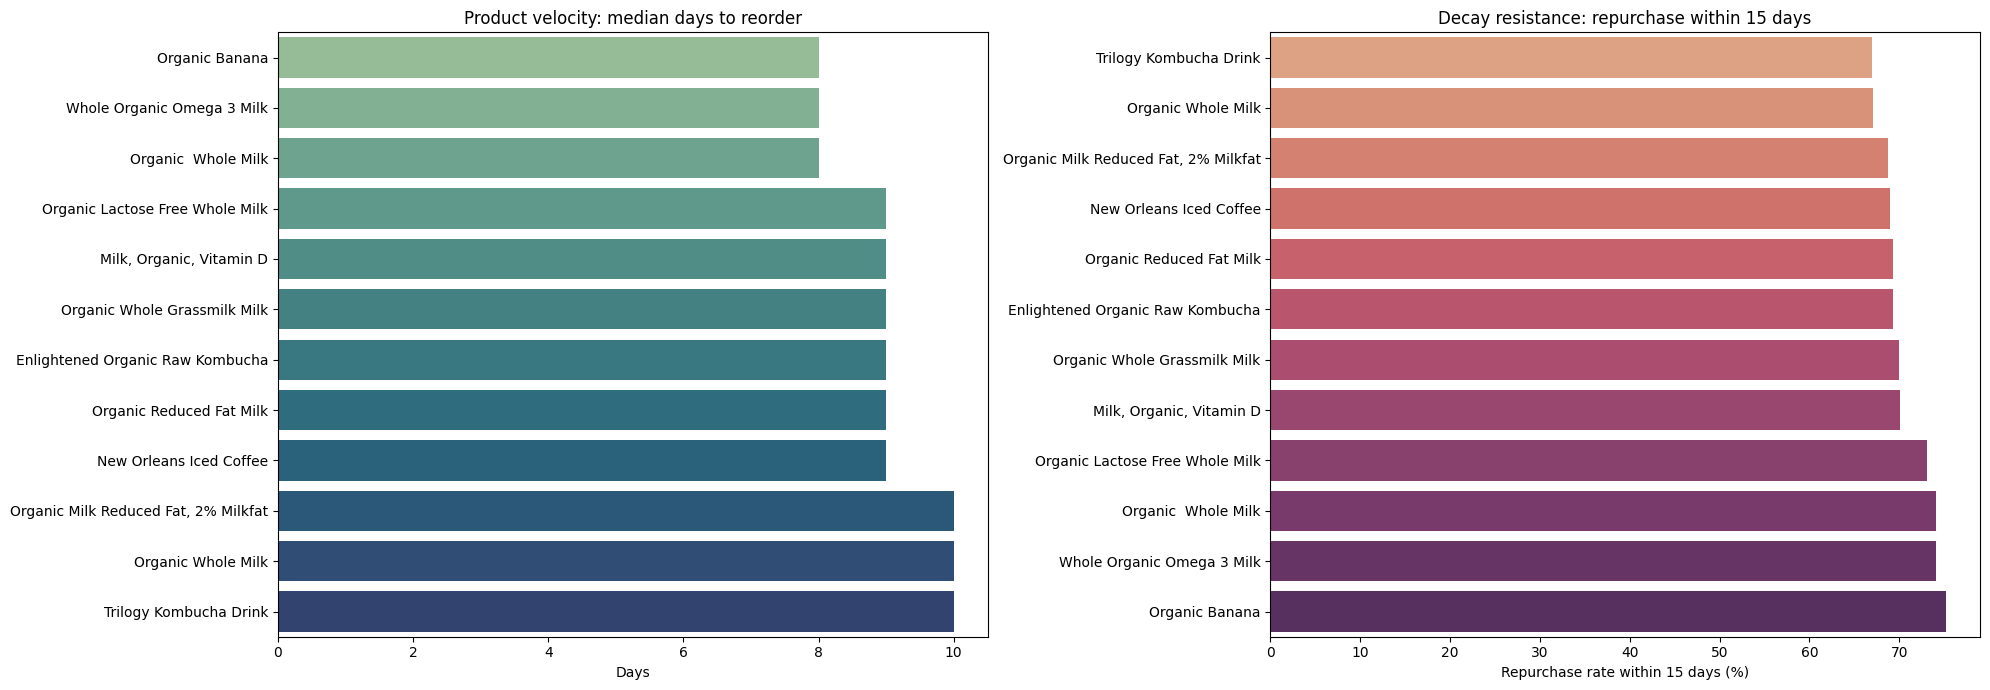

Top fast-repeat products:


product_id,product_name,repeat_events,avg_days_to_reorder,median_days_to_reorder,repurchase_within_15_pct
i64,str,u32,f64,f64,f64
37067,"""Organic Banana""",11016,13.034495,8.0,75.217865
45504,"""Whole Organic Omega 3 Milk""",7794,14.510008,8.0,74.056967
31720,"""Organic Whole Milk""",8224,14.742218,8.0,74.039397
43394,"""Organic Lactose Free Whole Mil…",7225,14.506851,9.0,73.038062
29447,"""Milk, Organic, Vitamin D""",17141,16.065515,9.0,70.08926
…,…,…,…,…,…
38689,"""Organic Reduced Fat Milk""",30145,16.399536,9.0,69.251949
7521,"""New Orleans Iced Coffee""",5488,17.576166,9.0,68.932216
13166,"""Organic Milk Reduced Fat, 2% M…",10605,17.205752,10.0,68.74116


Milk-related reorder cadence:


product_id,product_name,repeat_events,avg_days_to_reorder,median_days_to_reorder,repurchase_within_15_pct
i64,str,u32,f64,f64,f64
27845,"""Organic Whole Milk""",113657,17.664772,10.0,67.102774
35951,"""Organic Unsweetened Almond Mil…",43428,23.326126,14.0,55.0175
5785,"""Organic Reduced Fat 2% Milk""",38251,19.40344,11.0,64.625761
24838,"""Unsweetened Almondmilk""",37027,22.060064,13.0,57.603911
38689,"""Organic Reduced Fat Milk""",30145,16.399536,9.0,69.251949
23909,"""2% Reduced Fat Milk""",28435,19.762194,13.0,61.716195
4210,"""Whole Milk""",27418,18.74907,11.0,64.698373
47144,"""Unsweetened Original Almond Br…",24459,23.915491,14.0,53.976042
1463,"""Organic Milk""",22550,18.533437,10.0,66.155211


Interpretation: if a short-cycle product like milk is not repurchased within ~15 days, it is a strong retention warning signal.


In [6]:
# Compute per-product reorder cycle using diff() over user × product
product_events = (
    txn.select(["user_id", "product_id", "product_name", "relative_day"])
    .unique()
    .sort(["user_id", "product_id", "relative_day"])
    .with_columns(
        pl.col("relative_day")
        .diff()
        .over(["user_id", "product_id"])
        .alias("days_to_reorder")
    )
)
product_cycles = product_events.filter(pl.col("days_to_reorder").is_not_null())

product_velocity = (
    product_cycles.group_by(["product_id", "product_name"])
    .agg([
        pl.len().alias("repeat_events"),
        pl.col("days_to_reorder").mean().alias("avg_days_to_reorder"),
        pl.col("days_to_reorder").median().alias("median_days_to_reorder"),
        ((pl.col("days_to_reorder") <= 15).mean() * 100).alias("repurchase_within_15_pct"),
    ])
)

velocity_focus = (
    product_velocity.filter(pl.col("repeat_events") >= 5_000)
    .sort(["repurchase_within_15_pct", "repeat_events"], descending=[True, True])
    .head(12)
)
milk_focus = (
    product_velocity.filter(
        pl.col("product_name").str.contains("(?i)milk")
        & (pl.col("repeat_events") >= 5_000)
    )
    .sort("repeat_events", descending=True)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
_vf = velocity_focus.sort("median_days_to_reorder").to_pandas()
_vf2 = velocity_focus.sort("repurchase_within_15_pct").to_pandas()

sns.barplot(data=_vf, x="median_days_to_reorder", y="product_name", palette="crest", ax=axes[0])
axes[0].set_title("Product velocity: median days to reorder")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("")

sns.barplot(data=_vf2, x="repurchase_within_15_pct", y="product_name", palette="flare", ax=axes[1])
axes[1].set_title("Decay resistance: repurchase within 15 days")
axes[1].set_xlabel("Repurchase rate within 15 days (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

print("Top fast-repeat products:")
display(velocity_focus)

print("Milk-related reorder cadence:")
display(milk_focus)
print("Interpretation: if a short-cycle product like milk is not repurchased within ~15 days, it is a strong retention warning signal.")

## 5) Basket Intensity & Cross-Selling

สุดท้ายดูว่าในแต่ละวันและแต่ละ segment ตะกร้าแน่นแค่ไหน (`items per basket`) และหลากหลายกี่ category (`unique categories per basket`) เพื่อหา timing ที่เหมาะกับการทำ bundle deal หรือ cross-sell

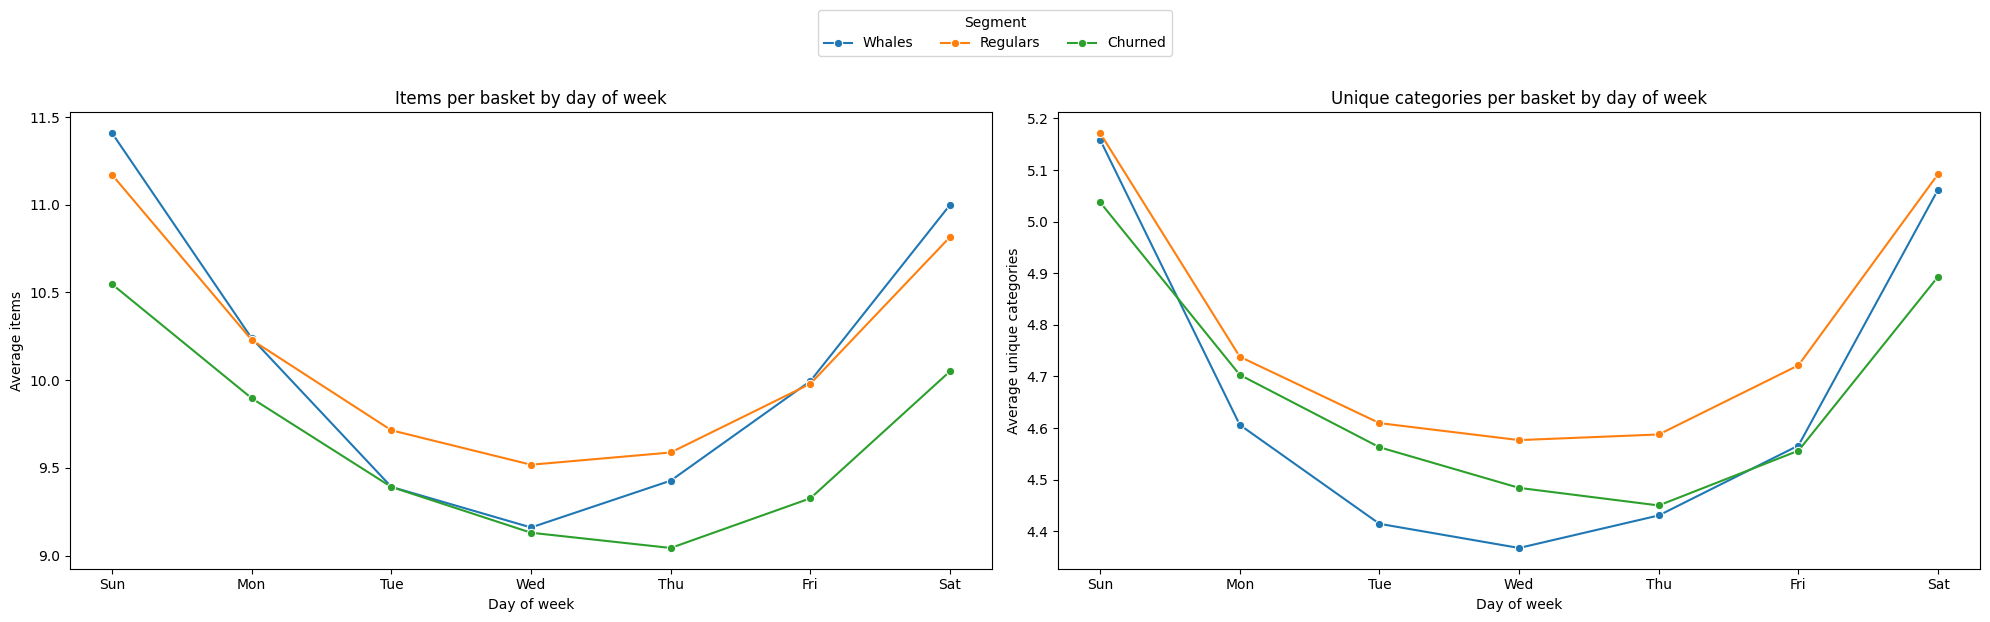

segment,day_name,avg_items,avg_unique_categories
str,str,f64,f64
"""Churned""","""Sun""",10.546896,5.037397
"""Regulars""","""Sun""",11.170692,5.171477
"""Whales""","""Sun""",11.408471,5.158658


Cross-sell implication: days with both larger baskets and more unique categories are the best windows for bundle deals and recommendation slots.


In [7]:
# Items and category diversity per basket, then averaged by segment × day
basket_metrics = (
    txn.group_by(["order_id", "segment", "day_name"])
    .agg([
        pl.col("product_id").count().alias("items_per_basket"),
        pl.col("department").n_unique().alias("unique_categories_per_basket"),
    ])
)

# Sort day_name into DOW_ORDER before converting to pandas for plotting
_day_order_df = pl.DataFrame({"day_name": DOW_ORDER, "_day_idx": list(range(len(DOW_ORDER)))})
basket_dow = (
    basket_metrics.group_by(["segment", "day_name"])
    .agg([
        pl.col("items_per_basket").mean().alias("avg_items"),
        pl.col("unique_categories_per_basket").mean().alias("avg_unique_categories"),
    ])
    .join(_day_order_df, on="day_name", how="left")
    .sort(["segment", "_day_idx"])
    .drop("_day_idx")
)

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharex=True)
_bd = basket_dow.to_pandas()

sns.lineplot(data=_bd, x="day_name", y="avg_items",
             hue="segment", hue_order=segment_order, marker="o", ax=axes[0])
axes[0].set_title("Items per basket by day of week")
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Average items")

sns.lineplot(data=_bd, x="day_name", y="avg_unique_categories",
             hue="segment", hue_order=segment_order, marker="o", ax=axes[1])
axes[1].set_title("Unique categories per basket by day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Average unique categories")

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(handles, labels, title="Segment", loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=3, frameon=True)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

basket_peak = (
    basket_dow.sort(["segment", "avg_items"], descending=[False, True])
    .with_columns(
        pl.col("avg_items")
        .rank(method="ordinal", descending=True)
        .over("segment")
        .alias("_rank")
    )
    .filter(pl.col("_rank") == 1)
    .drop("_rank")
    .sort("segment")
)
display(basket_peak)
print("Cross-sell implication: days with both larger baskets and more unique categories are the best windows for bundle deals and recommendation slots.")

## Executive takeaway

### What this notebook shows
- `Produce` and `dairy eggs` tend to dominate category share, but the mix shifts by segment and by day of week
- Some categories have strong **weekly signatures**, making them good candidates for timed promotions
- `Gateway` products are mostly essentials, while `Habit` products reveal where long-term trust and basket sophistication start to build
- Short-cycle staples with weak repurchase inside **15 days** are useful as early warning indicators
- Basket intensity is not constant through the week, which makes cross-sell timing a real lever

### Portfolio framing
- **Static profiling notebook** → who the customers are
- **This notebook** → how customer product choices evolve over time, across weekdays, and across reorder cycles